# Installation

### 1. Create a Conda Virtual Environment
Use the following command to create a new environment named `env_pytorch` with Python 3.14:
```bash
conda create -n env_pytorch python=3.14
```

### 2. Activate the environment
```bash
conda activate env_pytorch
```

### 3. Install the Jupyter Notebook
```bash
pip install jupyter
```

### 4. Install PyTorch
```bash
pip install torch torchvision
```

In [2]:
# To verify if PyTorch was installed correctly
import torch
x = torch.rand(5, 3)
print(x)

tensor([[0.6226, 0.2259, 0.1456],
        [0.8709, 0.6658, 0.3607],
        [0.4431, 0.6950, 0.8263],
        [0.9120, 0.5737, 0.2474],
        [0.1065, 0.9420, 0.6210]])


In [3]:
# To check the PyTorch version
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0


# PyTorch Introduction

## 1. Tensor creation and inspection

In [4]:
# create a tensor from a list
data = [[1, 2, 3], [4, 5, 6]]
tensor = torch.tensor(data, dtype=torch.float32)

# inspecting the shape, device, and type
print(f"shape: {tensor.shape}") #  useful for debugging size mismatches
print(f"device: {tensor.device}") # check if it's on CPU or GPU
print(f"Dtype: {tensor.dtype}") # check floats or integers

shape: torch.Size([2, 3])
device: cpu
Dtype: torch.float32


## 2. Reshaping (essential for creating/arranging a batch)

In [5]:
# create a flat vector
x = torch.randn(4)
print(x)

tensor([-0.1355, -0.0023,  1.2901, -0.0035])


In [6]:
# add a batch dimension at index 0, i.e., change the shape from [4] to [1, 4]
batch_x = x.unsqueeze(0)
print(batch_x)

tensor([[-0.1355, -0.0023,  1.2901, -0.0035]])


In [7]:
print(f"original: {x.shape}")
print(f"with batch dimension: {batch_x.shape}")

original: torch.Size([4])
with batch dimension: torch.Size([1, 4])


In [9]:
# reshape 1D (4) into 2D (2x2)
reshaped_x = x.view(2, 2)
print(reshaped_x)

tensor([[-0.1355, -0.0023],
        [ 1.2901, -0.0035]])


## 3. Stack and Concatenate

In [11]:
t1 = torch.tensor([1, 2])
t2 = torch.tensor([3, 4])
print(t1)
print(t2)

# concatenate: joins along an existing dimension
cat_t = torch.cat((t1, t2), dim=0)
print(cat_t)

tensor([1, 2])
tensor([3, 4])
tensor([1, 2, 3, 4])


In [13]:
# stack: joins along a new dimension (creating a batch)
stack_t = torch.stack((t1, t2))
print(stack_t)

tensor([[1, 2],
        [3, 4]])


## 4. The Data Pipeline (Dataset & DataLoader)


In cases where the training dataset is rather small and can be loaded as a tensor into the memory, we can
directly use this tensor for training. In typical use cases, however, **when the dataset is too large to fit
into the computer memory, we will need to load the data from the main storage device (for example,
the hard drive or solid-state drive) in chunks, that is, batch by batch**. (Note the use of the term “batch”
instead of “mini-batch” in this chapter to stay close to the PyTorch terminology.) In addition, we may
need to construct a data-processing pipeline to apply certain transformations and preprocessing steps
to our data, such as mean centering, scaling, or adding noise to augment the training procedure and
to prevent overfitting.

**Applying preprocessing functions manually every time can be quite cumbersome**. Luckily, PyTorch
provides a special class for constructing efficient and convenient preprocessing pipelines. In this sec-
tion, we will see an overview of different methods for constructing a PyTorch Dataset and DataLoader,
and implementing data loading, shuffling, and batching.

In [15]:
# The Dataloader handles shuffling (randomizing order) and batching (splitting the data into chucks)

from torch.utils.data import TensorDataset, DataLoader

In [16]:
# create data (features and labels)
X = torch.randn(100, 5) # 100 samples, 5 features
y = torch.randint(0, 2, (100,)) # 100 binary labels

In [17]:
# wrap in a dataset
dataset = TensorDataset(X, y)

In [18]:
# create DataLoader: handles shuffling and batching automatically
loader = DataLoader(dataset, batch_size=10, shuffle=True)

In [19]:
# Fetch one batch to verify
first_batch_X, first_batch_y = next(iter(loader))
print(f"Batch X shape: {first_batch_X.shape}")

Batch X shape: torch.Size([10, 5])


## 5. More on PyTorch

In [22]:
# creating tensors from numpy array
import numpy as np
b = np.array([4, 5, 6], dtype=np.int32)
t_b = torch.from_numpy(b) # t_b and b share the same underlying memory
print(t_b)

tensor([4, 5, 6], dtype=torch.int32)


In [26]:
# create special tensors
t_ones = torch.ones(2, 3)
print(t_ones)
t_zeros = torch.zeros(5, 2)
print(t_zeros)

tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])


In [24]:
# manipulating tensors
t = torch.rand(3, 5)
t_tr = torch.transpose(t, 0, 1)
print(t)
print(t_tr)

tensor([[0.5903, 0.5636, 0.6554, 0.8491, 0.2320],
        [0.3103, 0.8823, 0.3535, 0.2253, 0.5231],
        [0.6262, 0.3138, 0.5315, 0.8642, 0.4855]])
tensor([[0.5903, 0.3103, 0.6262],
        [0.5636, 0.8823, 0.3138],
        [0.6554, 0.3535, 0.5315],
        [0.8491, 0.2253, 0.8642],
        [0.2320, 0.5231, 0.4855]])


In [29]:
# removing the unnecessary dimension (dimension that have size 1)
t = torch.zeros(1, 2, 1, 4, 1)
t_sqz = torch.squeeze(t, 2) # remove the one with index 2
print(t.shape)
print(t_sqz.shape)

torch.Size([1, 2, 1, 4, 1])
torch.Size([1, 2, 4, 1])


In [34]:
# multiplying two tensors
torch.manual_seed(1)
t1 = 2 * torch.rand(5, 2) - 1   # generate uniform distribution [-1, 1]
t2 = torch.normal(mean=0, std=1, size=(5, 2)) # generate normal distribution of zero mean, and std=1
t3 = torch.multiply(t1, t2) # element-wise multiplication (they should have the same shape)
t3_prime = torch.matmul(t1, torch.transpose(t2, 0, 1)) # matrix-matrix multiplication
print(t1)
print(t2)
print(t3)
print(t3_prime)

tensor([[ 0.5153, -0.4414],
        [-0.1939,  0.4694],
        [-0.9414,  0.5997],
        [-0.2057,  0.5087],
        [ 0.1390, -0.1224]])
tensor([[ 0.8590,  0.7056],
        [-0.3406, -1.2720],
        [-1.1948,  0.0250],
        [-0.7627,  1.3969],
        [-0.3245,  0.2879]])
tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])
tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


In [35]:
# compute the mean, sum, std along a certain axis
t4 = torch.mean(t1, axis=0) # the mean of each column
print(t4)
t5 = torch.sum(t1, axis=1) # the sum of each row
print(t5)
t6 = torch.std(t2, axis=1) # the std of each row
print(t6)

tensor([-0.1373,  0.2028])
tensor([ 0.0739,  0.2755, -0.3417,  0.3030,  0.0166])
tensor([0.1085, 0.6586, 0.8626, 1.5271, 0.4330])


In [37]:
# computing the L^p norm of a tensor
norm_t1 = torch.linalg.norm(t1, ord=2, dim=1) # L^2 norm of t1)
print(norm_t1)

tensor([0.6785, 0.5078, 1.1162, 0.5488, 0.1853])


In [38]:
# split a tensor into two
torch.manual_seed(1)
t = torch.rand(6)
print(t)
t_splits = torch.chunk(t, 3)
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


[array([0.7576316 , 0.27931088], dtype=float32),
 array([0.40306926, 0.73468447], dtype=float32),
 array([0.02928156, 0.7998586 ], dtype=float32)]

In [40]:
# we can also specify the size of each chunk
torch.manual_seed(2)
t = torch.rand(5)
print(t)
t_splits = torch.split(t, split_size_or_sections=[3, 2])
[item.numpy() for item in t_splits]

tensor([0.6147, 0.3810, 0.6371, 0.4745, 0.7136])


[array([0.6146951 , 0.38101286, 0.63711435], dtype=float32),
 array([0.47446108, 0.71359384], dtype=float32)]

## 6. Creating a dataset from files on your local storage disk

In [43]:
# built a dataset from  image files (dogs, cats) stored on disk
import pathlib
imgdir_path = pathlib.Path('images_4_pytorch')
file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])
print(file_list)


['images_4_pytorch/cat-01.jpg', 'images_4_pytorch/cat-02.jpg', 'images_4_pytorch/cat-03.jpg', 'images_4_pytorch/dog-01.jpg', 'images_4_pytorch/dog-02.jpg', 'images_4_pytorch/dog-03.jpg']


Image shape: (4499, 3000, 3)
Image shape: (2500, 2392, 3)
Image shape: (1886, 2726, 3)
Image shape: (300, 450, 3)
Image shape: (400, 600, 3)
Image shape: (854, 1280, 3)


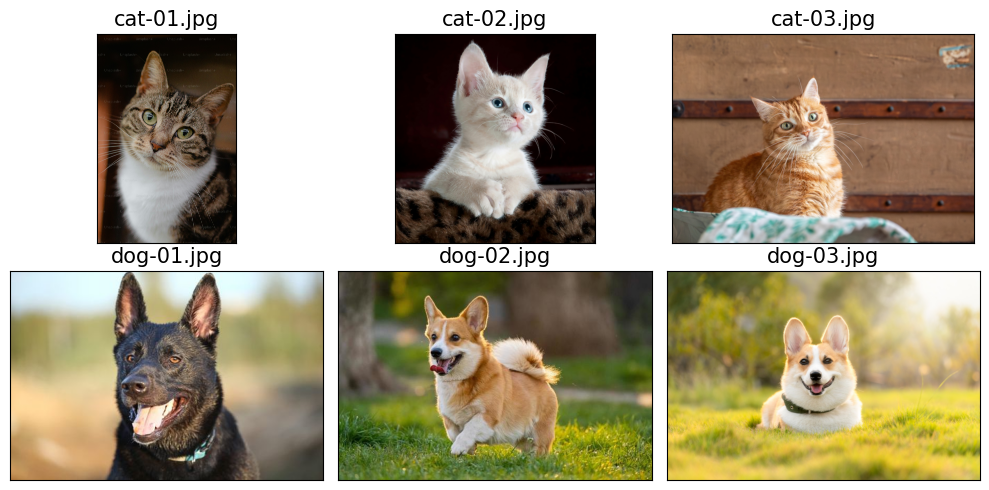

In [47]:
# now visualize these image examples using matplotlib
import matplotlib.pyplot as plt
import os
from PIL import Image # Image in PIL reads the image file contents

fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
    imag = Image.open(file)
    print('Image shape:', np.array(imag).shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(imag)
    ax.set_title(os.path.basename(file), size=15)

plt.tight_layout()
plt.show()

In [49]:
# extract the labels from the filename
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


In [54]:
from torch.utils.data import Dataset, DataLoader
# now create a joint dataset from the two arrays
class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __getitem__(self, index):
        file = self.file_list[index]
        label = self.labels[index]
        return file, label

    def __len__(self):
        return len(self.labels)

image_dataset = ImageDataset(file_list, labels)

for file, label in image_dataset:
    print(file, label)

images_4_pytorch/cat-01.jpg 0
images_4_pytorch/cat-02.jpg 0
images_4_pytorch/cat-03.jpg 0
images_4_pytorch/dog-01.jpg 1
images_4_pytorch/dog-02.jpg 1
images_4_pytorch/dog-03.jpg 1


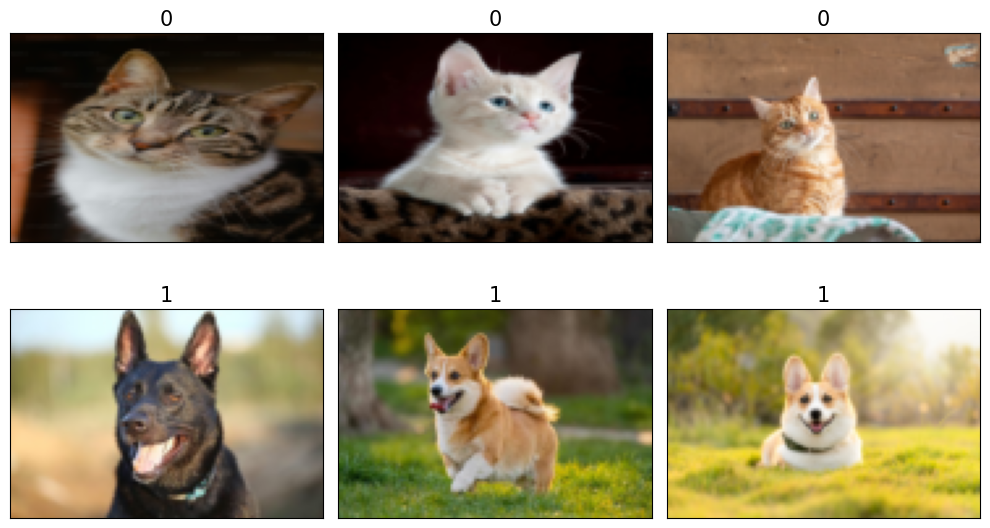

In [57]:
# load the image and decode the raw content, resize it to a desired size (80x120), convert into tensors
import torchvision.transforms as transforms
img_height, img_width = 80, 120
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width)),
])

# update the previously defined class 
class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __getitem__(self, index):
        img = Image.open(self.file_list[index])
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return img, label

    def __len__(self):
        return len(self.labels)

image_dataset = ImageDataset(file_list, labels, transform)

# then visualize these transformed image examples 
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1, 2, 0)))
    ax.set_title(f'{example[1]}', size=15)

plt.tight_layout()
plt.show()

## 7. Fetching datasets from torchvision.dataset library

In [64]:
import torchvision
image_path = './'   # local directory where the data will be stored, i.e., same folder as your notebook
mnist_dataset = torchvision.datasets.MNIST(image_path, 'train', download=True) # 'train' specifies that you want the training split of data
# 60000 images. If you want to get the evaluation set (10000images), you change this to "test")
# "download=True", if the dataset is not found in your path, PyTorch will automatically download it from the official server

In [66]:
# do a sanity check to ensure the object just created is compatible
assert isinstance(mnist_dataset, torch.utils.data.Dataset)

# assign
example = next(iter(mnist_dataset))
print(example)
example_feature, example_label = next(iter(mnist_dataset))
print(example_feature)
print(example_label)

(<PIL.Image.Image image mode=L size=28x28 at 0x327DCDF10>, 5)
<PIL.Image.Image image mode=L size=28x28 at 0x327DCD490>
5


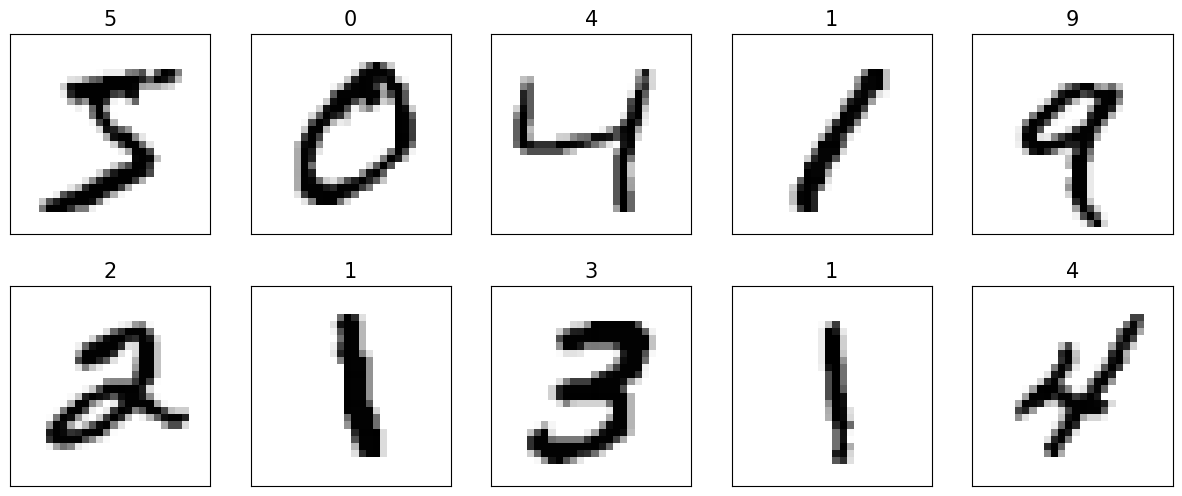

In [67]:
from itertools import islice
fig = plt.figure(figsize=(15, 6))
for i, (image, label) in islice(enumerate(mnist_dataset), 10): # take the first 10 data and visualize them
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}', size=15)
plt.show()

## Another dataset: Fashion MNIST

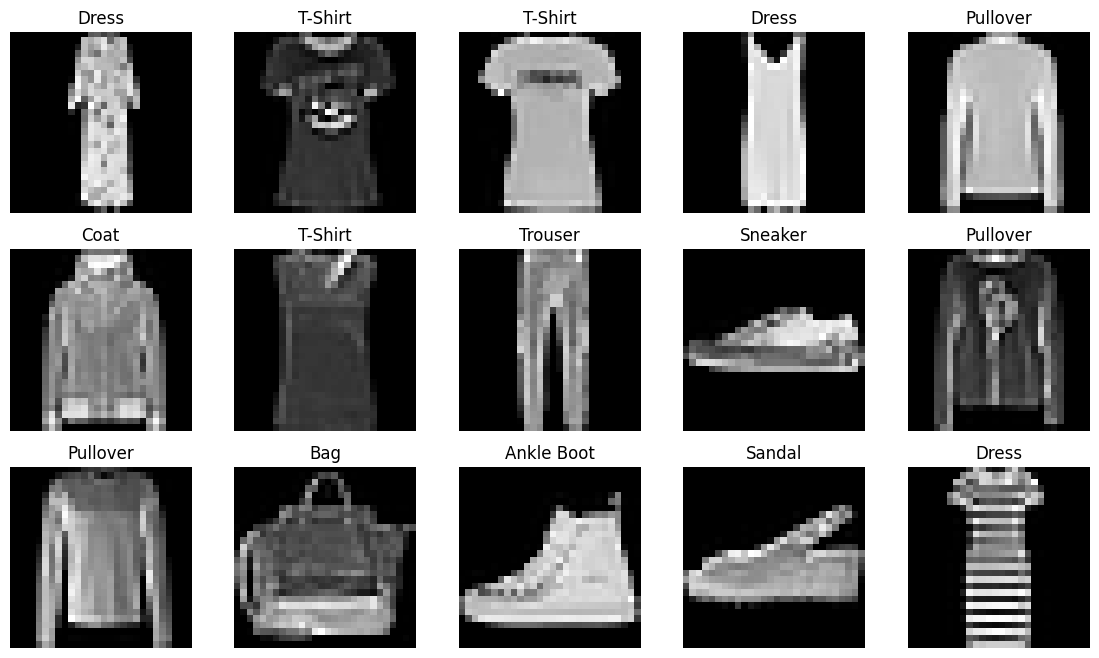

In [68]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data", # root is the path where the train/test data is stored
    train=True, # it specifies training of test dataset
    download=True, # it downloads the data from the internet if it's not available at root
    transform=ToTensor() # it specifies the label and feature tansformations
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)


# Mapping of class labels (0-9) to their corresponding clothing categories
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(14, 8))

cols, rows = 5, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item() # Pick a random index, .item() is used to convert a single-element
    # tensor with a single value
    img, label = training_data[sample_idx] # Get the corresponding image and label
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray") # squeeze() removes extra dimensions
    
plt.show()

# Building a CNN for the classification of the MNIST dataset in PyTorch

Epoch 1: Average Loss: 0.0000, Accuracy: 98.41%
Epoch 2: Average Loss: 0.0000, Accuracy: 98.73%


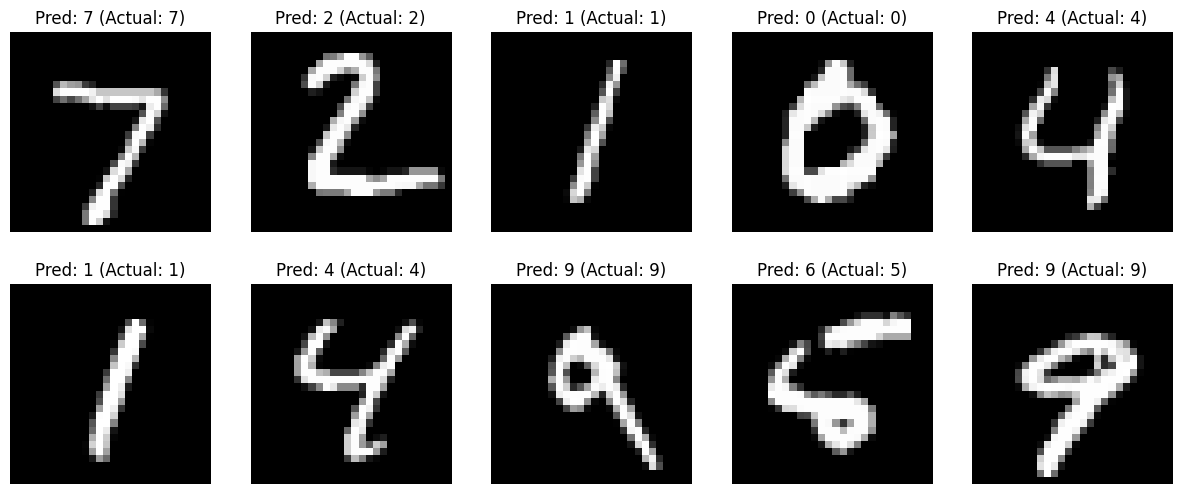

In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION & DATA LOADING ---
# We check if a GPU (CUDA) is available, otherwise we default to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformation pipeline: 
# 1. ToTensor: Converts images to [0, 1] range and switches format to (C, H, W).
# 2. Normalize: Subtracts mean (0.1307) and divides by std (0.3081) for MNIST stability.
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.1307,), (0.3081,))
])

# DataLoader: Handles batching (64 images at a time) and shuffling (to prevent memorizing order).
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./', train=False, transform=transform),
    batch_size=1000, shuffle=False
)

# --- 2. DEFINE CNN ARCHITECTURE ---
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        # Conv1: Learns 32 basic features (edges/lines) using a 3x3 window.
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        # Conv2: Learns 64 complex features (shapes/curves) from the previous 32.
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        
        # Dropout: Randomly "turns off" neurons to prevent the model from over-relying on specific pixels.
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        
        # Fully Connected (Dense) layers:
        # 9216 comes from the flattened output of the convolutional layers.
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10) # 10 output nodes for digits 0-9.

    def forward(self, x):
        # Apply layers: Convolution -> ReLU Activation -> Pooling
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2) # Reduces image size by half to focus on important features.
        x = self.dropout1(x)
        
        # Flatten: Converts the 2D feature maps into a 1D vector for the Dense layers.
        x = torch.flatten(x, 1)
        
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x) # Final raw scores (logits) for each of the 10 classes.
        return x

# Initialize model and move it to GPU/CPU.
model = MNIST_CNN().to(device)
# Adam: A popular optimizer that adjusts the learning rate automatically.
optimizer = optim.Adam(model.parameters(), lr=0.001)
# CrossEntropyLoss: The standard "punishment" function for classification tasks.
criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING & EVALUATION LOGIC ---
def train_and_test(model, device, train_loader, test_loader, optimizer, epochs=1):
    for epoch in range(1, epochs + 1):
        # TRAINING PHASE
        model.train() # Tell layers like Dropout to behave in "training mode."
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()  # Clear previous gradients.
            output = model(data)   # Forward pass: Predict digits.
            loss = criterion(output, target) # Calculate error.
            loss.backward()        # Backward pass: Calculate how to fix error.
            optimizer.step()       # Update weights.
            
        # EVALUATION PHASE
        model.eval() # Tell layers like Dropout to behave in "inference mode."
        test_loss = 0
        correct = 0
        with torch.no_grad(): # Disable gradient tracking to save memory and speed up.
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                test_loss += criterion(output, target).item()
                # Get the index of the highest probability (the prediction).
                pred = output.argmax(dim=1, keepdim=True)
                # Count how many predictions match the actual targets.
                correct += pred.eq(target.view_as(pred)).sum().item()

        test_loss /= len(test_loader.dataset)
        accuracy = 100. * correct / len(test_loader.dataset)
        print(f'Epoch {epoch}: Average Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%')

# --- 4. VISUALIZATION FUNCTION ---
def visualize_predictions(model, device, test_loader, num_images=10):
    model.eval()
    # Grab one batch of test images.
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        output = model(images)
        preds = output.argmax(dim=1)

    fig = plt.figure(figsize=(15, 6))
    for i in range(num_images):
        ax = fig.add_subplot(2, 5, i + 1)
        ax.axis('off')
        # Denormalize: Move back to CPU and remove the batch/channel dims for plotting.
        img = images[i].cpu().squeeze().numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Pred: {preds[i].item()} (Actual: {labels[i].item()})")
    plt.show()

# --- EXECUTION ---
train_and_test(model, device, train_loader, test_loader, optimizer, epochs=2)
visualize_predictions(model, device, test_loader)

# Building a RNN/LSTM for sequential data learning

Even though MNIST is an image dataset, we can convert it to a sequence.
Example conversion: 28×28 image becomes 28 time steps with each step = 28 pixels

So the input becomes: (sequence_length = 28, feature_dim = 28)

Then an RNN/LSTM can process it row by row.

This trick is called: Sequential MNIST. It is commonly used in deep learning tutorials.

Using device: cpu


100.0%
100.0%
100.0%
100.0%


Train size: 54000
Val size:   6000
Test size:  10000
SequenceClassifier(
  (rnn): LSTM(28, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


/opt/anaconda3/envs/env_pytorch/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/5 | train_loss=0.6065 | train_acc=0.7995 | val_loss=0.1847 | val_acc=0.9473 | lr=1.00e-03 | time=32.0s
Epoch 02/5 | train_loss=0.1629 | train_acc=0.9513 | val_loss=0.1132 | val_acc=0.9663 | lr=1.00e-03 | time=19.8s
Epoch 03/5 | train_loss=0.1059 | train_acc=0.9684 | val_loss=0.0978 | val_acc=0.9733 | lr=1.00e-03 | time=20.2s
Epoch 04/5 | train_loss=0.0787 | train_acc=0.9764 | val_loss=0.0717 | val_acc=0.9788 | lr=1.00e-03 | time=19.5s
Epoch 05/5 | train_loss=0.0640 | train_acc=0.9808 | val_loss=0.0592 | val_acc=0.9812 | lr=1.00e-03 | time=19.6s

Best validation accuracy: 0.9812
Test loss: 0.0568
Test accuracy: 0.9825


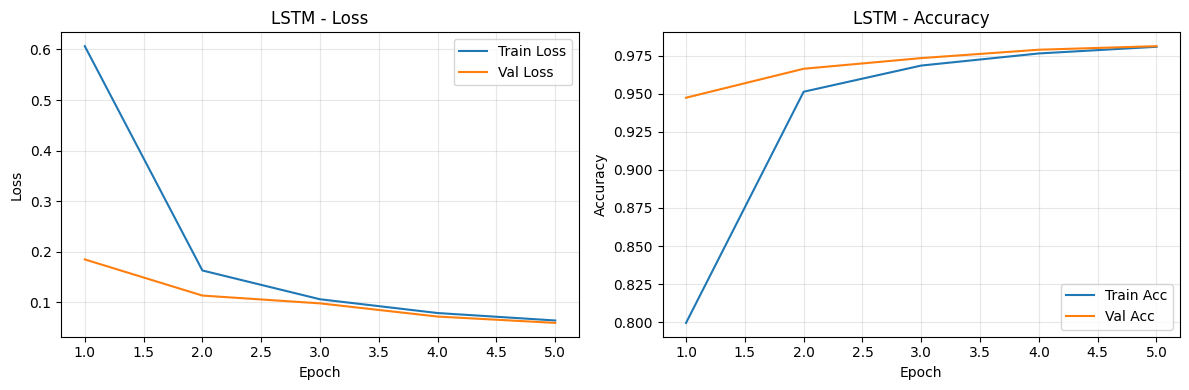

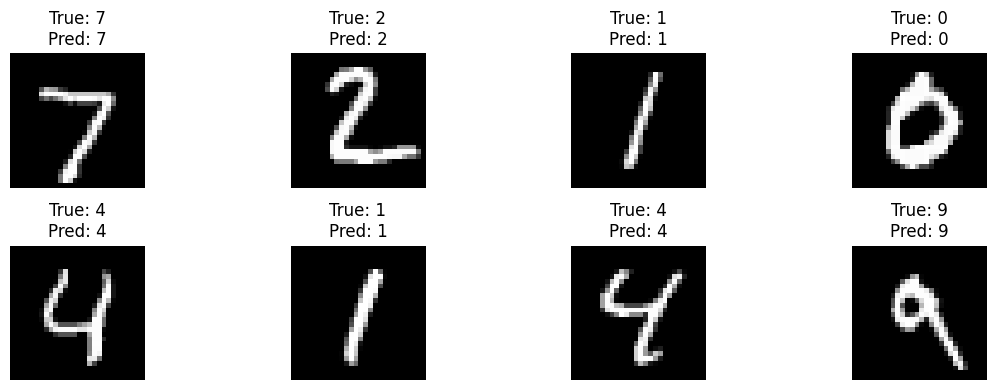

In [77]:
# =========================
# RNN / LSTM on sequential MNIST with PyTorch
# Jupyter-ready full example
# =========================

import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# -------------------------
# 1. Reproducibility
# -------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# -------------------------
# 2. Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# 3. Hyperparameters
# -------------------------
MODEL_TYPE = "LSTM"   # Options: "RNN", "LSTM"
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS = 5
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_CLASSES = 10
INPUT_SIZE = 28       # Each row has 28 pixels
SEQ_LEN = 28          # 28 rows -> sequence length 28
DROPOUT = 0.2
VALID_RATIO = 0.1

# -------------------------
# 4. Dataset: MNIST from torchvision
# Treat each image as a sequence of 28 steps,
# each step = 28 features.
# -------------------------
transform = transforms.Compose([
    transforms.ToTensor(),  # shape: [1, 28, 28], values in [0,1]
])

train_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Split train into train/validation
num_train = int((1.0 - VALID_RATIO) * len(train_full))
num_val = len(train_full) - num_train
train_dataset, val_dataset = random_split(train_full, [num_train, num_val])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")
print(f"Test size:  {len(test_dataset)}")

# -------------------------
# 5. Model
# -------------------------
class SequenceClassifier(nn.Module):
    def __init__(
        self,
        model_type: str = "LSTM",
        input_size: int = 28,
        hidden_size: int = 128,
        num_layers: int = 2,
        num_classes: int = 10,
        dropout: float = 0.2
    ):
        super().__init__()
        self.model_type = model_type.upper()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        if self.model_type == "RNN":
            self.rnn = nn.RNN(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                nonlinearity="tanh",
                dropout=dropout if num_layers > 1 else 0.0
            )
        elif self.model_type == "LSTM":
            self.rnn = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0
            )
        else:
            raise ValueError("MODEL_TYPE must be either 'RNN' or 'LSTM'.")

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        x shape: [batch, seq_len, input_size]
        For MNIST: [batch, 28, 28]
        """
        batch_size = x.size(0)

        if self.model_type == "RNN":
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
            out, hn = self.rnn(x, h0)
            last_hidden = out[:, -1, :]  # last time step
        else:  # LSTM
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
            c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
            out, (hn, cn) = self.rnn(x, (h0, c0))
            last_hidden = out[:, -1, :]  # last time step

        logits = self.fc(self.dropout(last_hidden))
        return logits

model = SequenceClassifier(
    model_type=MODEL_TYPE,
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

print(model)

# -------------------------
# 6. Loss and optimizer
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Optional scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

# -------------------------
# 7. Helper functions
# -------------------------
def prepare_batch(images, labels):
    """
    images from MNIST are [batch, 1, 28, 28]
    Convert to [batch, 28, 28]
    """
    images = images.squeeze(1)  # [batch, 28, 28]
    return images.to(device), labels.to(device)

def accuracy_from_logits(logits, labels):
    preds = torch.argmax(logits, dim=1)
    acc = (preds == labels).float().mean().item()
    return acc

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = prepare_batch(images, labels)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

# -------------------------
# 8. Training loop
# -------------------------
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    elapsed = time.time() - start_time
    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | "
        f"lr={current_lr:.2e} | time={elapsed:.1f}s"
    )

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)

# -------------------------
# 9. Test evaluation
# -------------------------
test_loss, test_acc = run_epoch(model, test_loader, criterion)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# -------------------------
# 10. Plot training curves
# -------------------------
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{MODEL_TYPE} - Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_TYPE} - Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------
# 11. Show a few predictions
# -------------------------
model.eval()

images, labels = next(iter(test_loader))
images_seq, labels = prepare_batch(images, labels)

with torch.no_grad():
    logits = model(images_seq)
    preds = torch.argmax(logits, dim=1)

# Plot first 8 examples
plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"True: {labels[i].item()}\nPred: {preds[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Building a RNN/LSTM for sequential data learning (Chaotic logistic map)

Using device: cpu


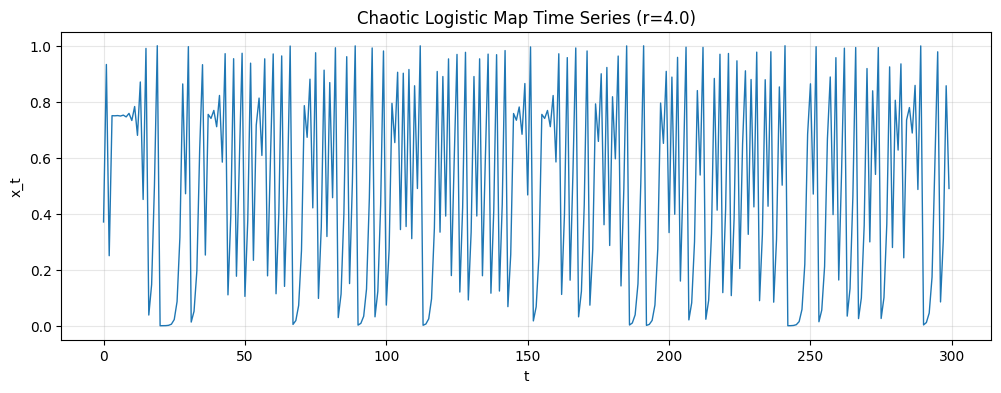

Train samples: 10480
Val samples:   2230
Test samples:  2230
LogisticLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Epoch 01/25 | Train MSE: 0.15904924 | Val MSE: 0.12824214
Epoch 02/25 | Train MSE: 0.12744994 | Val MSE: 0.12922969
Epoch 03/25 | Train MSE: 0.12728849 | Val MSE: 0.12812161
Epoch 04/25 | Train MSE: 0.12723456 | Val MSE: 0.13008893
Epoch 05/25 | Train MSE: 0.12738728 | Val MSE: 0.12854851
Epoch 06/25 | Train MSE: 0.12776712 | Val MSE: 0.12815315
Epoch 07/25 | Train MSE: 0.12679035 | Val MSE: 0.12706946
Epoch 08/25 | Train MSE: 0.12551687 | Val MSE: 0.12459157
Epoch 09/25 | Train MSE: 0.11930653 | Val MSE: 0.10897732
Epoch 10/25 | Train MSE: 0.08780112 | Val MSE: 0.03835776
Epoch 11/25 | Train MSE: 0.03287209 | Val MSE: 0.00637511
Epoch 12/25 | Train MSE: 0.01873990 | Val MSE: 0.00370510
Epoch 13/25 | Train MSE: 0.01246659 | Val MSE: 0.00165591
Epoch 14/25 | Train MSE: 0.00933781 | Val MS

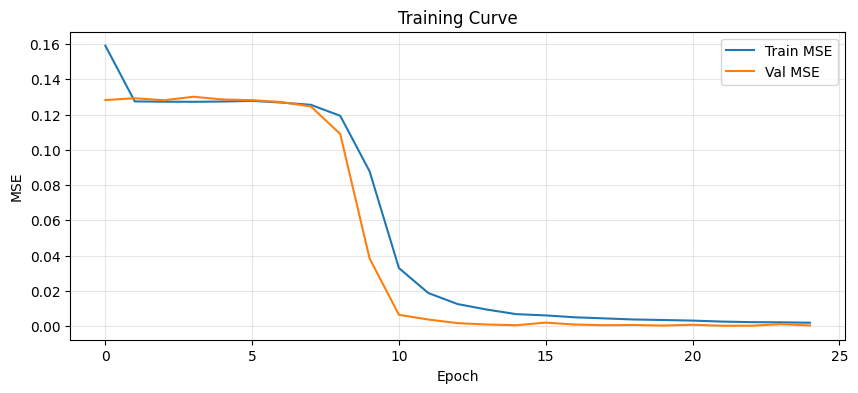

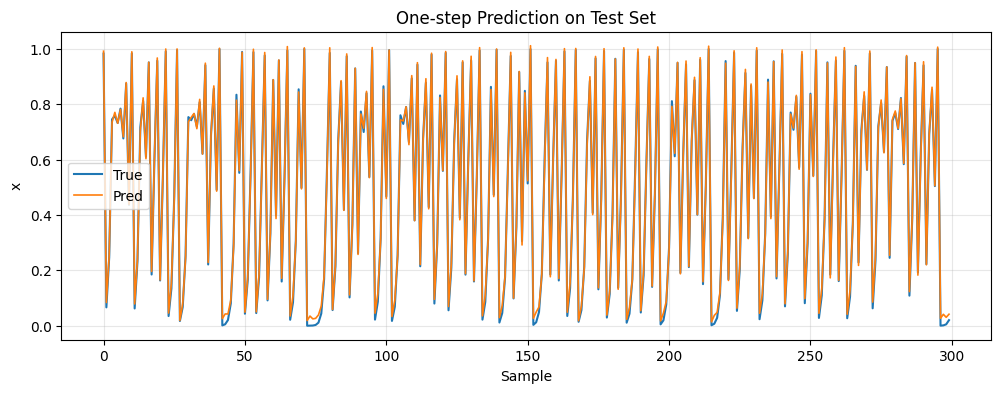

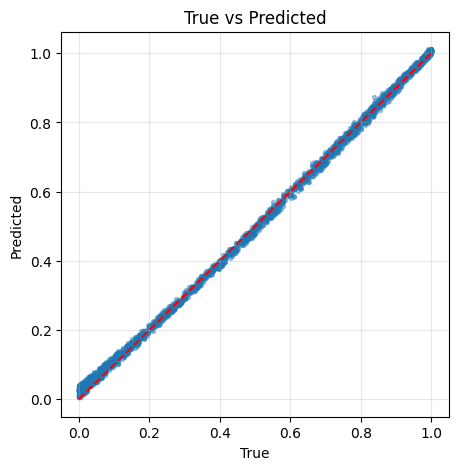

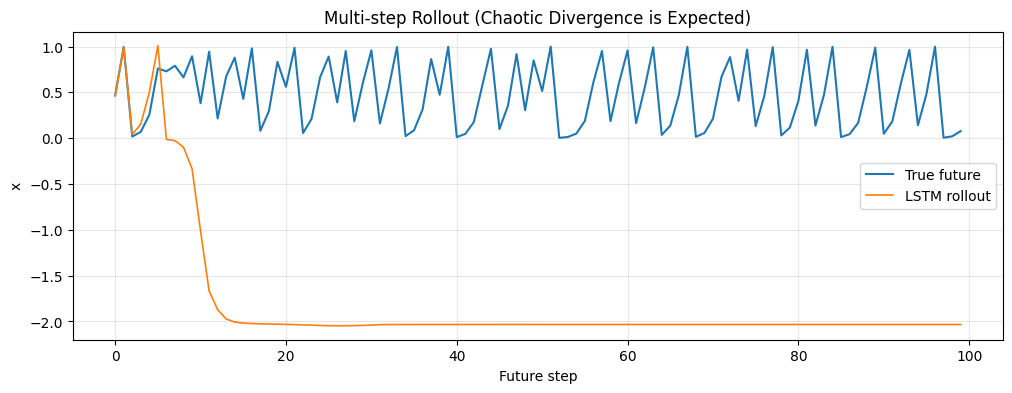

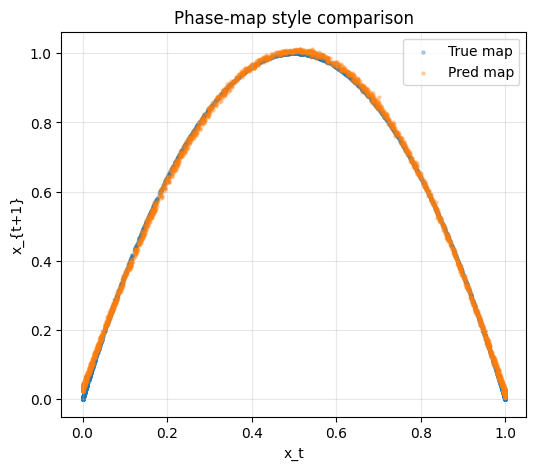

In [79]:
# ============================================
# LSTM for Chaotic Logistic Map Prediction
# ============================================

import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------------
# 1. Reproducibility
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# 2. Logistic map generator
# x_{t+1} = r x_t (1 - x_t)
# -------------------------
def generate_logistic_map(r=4.0, x0=0.1234, n_steps=12000, discard=200):
    x = np.zeros(n_steps + discard, dtype=np.float32)
    x[0] = x0
    for t in range(n_steps + discard - 1):
        x[t + 1] = r * x[t] * (1.0 - x[t])
    return x[discard:]  # remove transient (before it becomes fully chaotic)

# Generate one long chaotic trajectory
r = 4.0
series = generate_logistic_map(r=r, x0=0.123456, n_steps=15000, discard=500)

plt.figure(figsize=(12, 4))
plt.plot(series[:300], lw=1)
plt.title(f"Chaotic Logistic Map Time Series (r={r})")
plt.xlabel("t")
plt.ylabel("x_t")
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 3. Build supervised sequences of length L
# Input:  x_t, x_{t+1}, ..., x_{t+L-1}
# Target: x_{t+L}
# -------------------------
SEQ_LEN = 20

class LogisticDataset(Dataset):
    def __init__(self, series, seq_len=20):
        self.series = series.astype(np.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.series) - self.seq_len

    def __getitem__(self, idx):
        x_seq = self.series[idx : idx + self.seq_len]
        y = self.series[idx + self.seq_len]

        # shape for LSTM: [seq_len, input_size]
        x_seq = torch.tensor(x_seq, dtype=torch.float32).unsqueeze(-1)  # [L, 1]
        y = torch.tensor(y, dtype=torch.float32)
        return x_seq, y

# Train, validaton, test split
n = len(series)
train_end = int(0.7 * n) # 70% for training
val_end = int(0.85 * n) # the next 15% for validation, remaining 15% for testing

train_series = series[:train_end]
val_series = series[train_end:val_end]
test_series = series[val_end:]

train_dataset = LogisticDataset(train_series, seq_len=SEQ_LEN)
val_dataset = LogisticDataset(val_series, seq_len=SEQ_LEN)
test_dataset = LogisticDataset(test_series, seq_len=SEQ_LEN)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_dataset))
print("Val samples:  ", len(val_dataset))
print("Test samples: ", len(test_dataset))

# -------------------------
# 4. Define LSTM model
# -------------------------
class LogisticLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch, seq_len, 1]
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]      # [batch, hidden_size]
        yhat = self.fc(last_hidden)      # [batch, 1]
        return yhat.squeeze(-1)          # [batch]

model = LogisticLSTM(input_size=1, hidden_size=64, num_layers=2, dropout=0.1).to(device)
print(model)

# -------------------------
# 5. Training setup
# -------------------------
EPOCHS = 25
LR = 1e-3

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# -------------------------
# 6. Train / evaluate helpers
# -------------------------
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    total_count = 0

    with torch.set_grad_enabled(train_mode):
        for x_seq, y in loader:
            x_seq = x_seq.to(device)   # [B, L, 1] # move data to the save device (CPU/GPU) as the model
            y = y.to(device)           # [B]

            yhat = model(x_seq)    # forward pass, compute prediction yhat
            loss = criterion(yhat, y)

            if train_mode:
                optimizer.zero_grad() # clear gradients from previous batch
                loss.backward()  # backpropagation
                optimizer.step() # update model weights based on gradients

            batch_size = x_seq.size(0)
            total_loss += loss.item() * batch_size # loss is usually averaged over the batch, multiplying batch_size to get cumulative loss
            total_count += batch_size

    return total_loss / total_count

# -------------------------
# 7. Training loop
# -------------------------
history = {
    "train_loss": [],
    "val_loss": []
}

best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer)
    val_loss = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train MSE: {train_loss:.8f} | Val MSE: {val_loss:.8f}")

# Load best model
model.load_state_dict(best_state)

# -------------------------
# 8. Test loss
# -------------------------
test_loss = run_epoch(model, test_loader, criterion)
print(f"\nBest Val MSE: {best_val:.8f}")
print(f"Test MSE:     {test_loss:.8f}")

# -------------------------
# 9. Plot training curves
# -------------------------
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="Train MSE")
plt.plot(history["val_loss"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 10. One-step prediction on test set
# -------------------------
model.eval()

all_targets = []
all_preds = []

with torch.no_grad():
    for x_seq, y in test_loader:
        x_seq = x_seq.to(device)
        yhat = model(x_seq).cpu().numpy()
        all_preds.append(yhat)
        all_targets.append(y.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

plt.figure(figsize=(12, 4))
plt.plot(all_targets[:300], label="True", lw=1.5)
plt.plot(all_preds[:300], label="Pred", lw=1.2)
plt.title("One-step Prediction on Test Set")
plt.xlabel("Sample")
plt.ylabel("x")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 11. Scatter plot: true vs pred
# -------------------------
plt.figure(figsize=(5, 5))
plt.scatter(all_targets, all_preds, s=8, alpha=0.4)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 12. Multi-step rollout from one seed sequence
# -------------------------
start_idx = 100
seed_seq = test_series[start_idx : start_idx + SEQ_LEN].copy()
future_true = test_series[start_idx + SEQ_LEN : start_idx + SEQ_LEN + 100].copy()

roll_input = seed_seq.copy()
future_pred = []

model.eval()
with torch.no_grad():
    for _ in range(len(future_true)):
        x_in = torch.tensor(roll_input[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
        next_pred = model(x_in).item()
        future_pred.append(next_pred)
        roll_input = np.append(roll_input, next_pred)

future_pred = np.array(future_pred, dtype=np.float32)

plt.figure(figsize=(12, 4))
plt.plot(future_true, label="True future", lw=1.5)
plt.plot(future_pred, label="LSTM rollout", lw=1.2)
plt.title("Multi-step Rollout (Chaotic Divergence is Expected)")
plt.xlabel("Future step")
plt.ylabel("x")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 13. phase map comparison
# logistic map often visualized as x_{t+1} vs x_{t}
# -------------------------
plt.figure(figsize=(6, 5))
plt.scatter(all_targets[:-1], all_targets[1:], s=5, alpha=0.3, label="True map")
plt.scatter(all_targets[:-1], all_preds[1:], s=5, alpha=0.3, label="Pred map")
plt.xlabel("x_t")
plt.ylabel("x_{t+1}")
plt.title("Phase-map style comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()